# AutoML using H2O library 

H2O AutoML is a powerful tool that automates the process of training and tuning a large selection of machine learning models. It allows users to easily find the best model for their data without having to manually tune hyperparameters or select algorithms. Here’s a detailed guide on how to use H2O AutoML.

## Background 
This dataset represents customer credit and demographic information collected by a financial institution (such as a bank or lending company). The primary objective of the analysis is to predict whether a customer will be classified as a “bad” credit risk (loan default or high-risk borrower) based on their financial liabilities, account behavior, employment stability, and personal demographics.

## Data Description 

| Column Name | Description |
|------------|------------|
| `custid` | Unique customer identifier |
| `debtinc` | Debt to income ratio |
| `creddebt` | Credit card debt amount |
| `othdebt` | Other outstanding debts |
| `preloan` | Previous loan history indicator |
| `veh` | Vehicle ownership status |
| `house` | House ownership status |
| `selfemp` | Self-employed indicator |
| `account` | Bank account indicator |
| `deposit` | Deposit holding indicator |
| `emp` | Length of employment |
| `address` | Years at current address |
| `branch` | Bank branch code |
| `ref` | Reference availability indicator |
| `age` | Age group code |
| `gender` | Gender code |
| `ms` | Marital status code |
| `child` | Children / dependent indicator |
| `zone` | Residential zone / region code |
| `bad`       | **Target variable – Credit risk flag** |


### 1. Import the necessary libraries and initialize the H2O cluster:


In [1]:
import h2o
from h2o.automl import H2OAutoML

# Initialize the H2O cluster
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; Java HotSpot(TM) 64-Bit Server VM (build 23+37-2369, mixed mode, sharing)
  Starting server from C:\Users\Fimran\anaconda3\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\Fimran\AppData\Local\Temp\tmpqf4nzbja
  JVM stdout: C:\Users\Fimran\AppData\Local\Temp\tmpqf4nzbja\h2o_Fimran_started_from_python.out
  JVM stderr: C:\Users\Fimran\AppData\Local\Temp\tmpqf4nzbja\h2o_Fimran_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,05 secs
H2O_cluster_timezone:,Asia/Kolkata
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.5
H2O_cluster_version_age:,"1 year, 6 months and 4 days"
H2O_cluster_name:,H2O_from_python_Fimran_ezpbnu
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.908 Gb
H2O_cluster_total_cores:,12
H2O_cluster_allowed_cores:,12
H2O_cluster_status:,"locked, healthy"


### 2. Load the dataset into an H2OFrame:

Import dataset as h20 dataframe

In [2]:
data = h2o.import_file("Credit Scoring Data.csv")
type(data)

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


h2o.frame.H2OFrame

### Note :
H2O runs on its own JVM backend (Java engine).
So data must be converted into H2O’s optimized distributed format → H2OFrame.

### 3. Converting Data Types
H2O will treat integer columns as numeric by default, even if they actually represent categories (1–3, 1–5, etc.).

You must explicitly convert them to factor if they are categorical.

In [5]:
cols_to_factor = ["bad", "preloan", "veh", "house", "selfemp", "account", "deposit", 
                  "branch", "ref", "age", "gender", "ms", "child", "zone"]

# Convert the specified columns to factors using asfactor()
for col in cols_to_factor:
    if col in data.columns:
        data[col] = data[col].asfactor()


In [7]:
data.types

{'custid': 'int',
 'debtinc': 'real',
 'creddebt': 'real',
 'othdebt': 'real',
 'preloan': 'enum',
 'veh': 'enum',
 'house': 'enum',
 'selfemp': 'enum',
 'account': 'enum',
 'deposit': 'enum',
 'emp': 'int',
 'address': 'int',
 'branch': 'enum',
 'ref': 'enum',
 'age': 'enum',
 'gender': 'enum',
 'ms': 'enum',
 'child': 'enum',
 'zone': 'enum',
 'bad': 'enum'}

### 4. Split the dataset into training and testing sets:
Explicitly run split_frame() first and then pass the frames to AutoML.

In [5]:
# Split the dataset into training and testing sets
train, test = data.split_frame(ratios=[.8], seed=42)

# Define target and features
target = "bad"
features = data.columns
features.remove(target)
features.remove("custid")  # Remove non-numeric column


### 5. List of Features/Independent Variables

In [6]:
list(features) #Independent variables.

['debtinc',
 'creddebt',
 'othdebt',
 'preloan',
 'veh',
 'house',
 'selfemp',
 'account',
 'deposit',
 'emp',
 'address',
 'branch',
 'ref',
 'age',
 'gender',
 'ms',
 'child',
 'zone']

### 6. Train a model using H2O's AutoML:


H2O AutoML performs a comprehensive set of preprocessing and modeling steps automatically by default. Here's an overview of the key operations it performs:

#### H2O AutoML – What It Does Automatically

- **Preprocessing:** Handles missing values, encodes categoricals, standardizes when required, supports text, does not explicitly remove outliers.  

- **Model Training:** Trains GBM, Random Forest, GLM, XRT, Deep Learning, and builds Stacked Ensembles (Best of Family + All Models).  

- **Hyperparameter Tuning:** Automatic tuning via grid/random search.  

- **Cross-Validation:** Uses k-fold CV by default.  

- **Model Selection:** Ranks models using chosen metric (AUC, RMSE, etc.) and selects best for ensembling.  

- **Early Stopping:** Stops training to prevent overfitting.  

- **Explainability:** Provides SHAP, Partial Dependence Plots, and Variable Importance.  

In [7]:
# Initialize H2OAutoML
aml = H2OAutoML(max_models=20, seed=42,max_runtime_secs = 400)

# Train the model
aml.train(x=features, y=target, training_frame=train)


AutoML progress: |
14:12:06.868: AutoML: XGBoost is not available; skipping it.

███████████████████████████████████████████████████████████████| (done) 100%


Model Details
=============
H2OGradientBoostingEstimator : Gradient Boosting Machine
Model Key: GBM_5_AutoML_1_20260304_141206


Model Summary: 
    number_of_trees    number_of_internal_trees    model_size_in_bytes    min_depth    max_depth    mean_depth    min_leaves    max_leaves    mean_leaves
--  -----------------  --------------------------  ---------------------  -----------  -----------  ------------  ------------  ------------  -------------
    41                 41                          32534                  6            6            6             46            64            58.5366

ModelMetricsBinomial: gbm
** Reported on train data. **

MSE: 0.05798879407987211
RMSE: 0.24080862542664894
LogLoss: 0.20296083091017397
Mean Per-Class Error: 0.11968677750961834
AUC: 0.9691640338538748
AUCPR: 0.8590739648122675
Gini: 0.9383280677077497

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.2811249925833942
       0     1    Error    Rate
-----  ----  ---  -------  --------------
0      4692  169  0.0348   (169.0/4861.0)
1      151   587  0.2046   (151.0/738.0)
Total  4843  756  0.0572   (320.0/5599.0)

Maximum Metrics: Maximum metrics at their respective thresholds
metric                       threshold    value     idx
---------------------------  -----------  --------  -----
max f1                       0.281125     0.78581   172
max f2                       0.22216      0.815327  205
max f0point5                 0.350316     0.812967  141
max accuracy                 0.311901     0.945169  157
max precision                0.854617     1         0
max recall                   0.0545531    1         337
max specificity              0.854617     1         0
max absolute_mcc             0.281125     0.752912  172
max min_per_class_accuracy   0.203094     0.899198  218
max mean_per_class_accuracy  0.174154     0.901848  235
max tns                      0.854617     4861      0
max fns                      0.854617     736       0
max fps                      0.00710141   4861      399
max tps                      0.0545531    738       337
max tnr                      0.854617     1         0
max fnr                      0.854617     0.99729   0
max fpr                      0.00710141   1         399
max tpr                      0.0545531    1         337

Gains/Lift Table: Avg response rate: 13.18 %, avg score: 13.20 %
group    cumulative_data_fraction    lower_threshold    lift       cumulative_lift    response_rate    score      cumulative_response_rate    cumulative_score    capture_rate    cumulative_capture_rate    gain      cumulative_gain    kolmogorov_smirnov
-------  --------------------------  -----------------  ---------  -----------------  ---------------  ---------  --------------------------  ------------------  --------------  -------------------------  --------  -----------------  --------------------
1        0.0100018                   0.717464           7.58672    7.58672            1                0.775481   1                           0.775481            0.0758808       0.0758808                  658.672   658.672            0.0758808
2        0.0200036                   0.645821           7.45124    7.51898            0.982143         0.680498   0.991071                    0.727989            0.0745257       0.150407                   645.124   651.898            0.150201
3        0.0300054                   0.589827           7.18029    7.40608            0.946429         0.622336   0.97619                     0.692771            0.0718157       0.222222                   618.029   640.608            0.221399
4        0.0400071                   0.550198           7.31577    7.38351            0.964286         0.570776   0.973214                    0.662272            0.0731707       0.295393                   631.577   638.351            0.294159
5        0.0500089                   0.505429           6.90934    7.28867            0.910714         0.527797   0.960714                    0.63

### 7. View leaderboard:
The leaderboard is a ranked table of all the models trained during an AutoML run, sorted by performance on a specified evaluation metric (e.g., AUC for classification or RMSE for regression). It helps users easily compare and identify the best models generated by H2O AutoML.

### Note :
H2O reports RMSE/MSE as probability error metrics, not class-label accuracy.

In [8]:
# View the AutoML leaderboard
aml.leaderboard


model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse
GBM_5_AutoML_1_20260304_141206,0.799184,0.321845,0.368843,0.285999,0.313623,0.0983594
GBM_3_AutoML_1_20260304_141206,0.797276,0.325308,0.359837,0.288801,0.315105,0.0992914
GBM_2_AutoML_1_20260304_141206,0.793162,0.326505,0.351833,0.291428,0.315963,0.0998326
GBM_4_AutoML_1_20260304_141206,0.792471,0.330147,0.342931,0.316141,0.317891,0.101054
GBM_1_AutoML_1_20260304_141206,0.790935,0.3247,0.354853,0.307383,0.314626,0.0989897
GBM_grid_1_AutoML_1_20260304_141206_model_5,0.781698,0.336529,0.334397,0.313841,0.319423,0.102031
GBM_grid_1_AutoML_1_20260304_141206_model_2,0.779318,0.337171,0.342177,0.297754,0.319859,0.102309
GBM_grid_1_AutoML_1_20260304_141206_model_4,0.778942,0.33781,0.334395,0.299292,0.320145,0.102493
XRT_1_AutoML_1_20260304_141206,0.778481,0.335497,0.323879,0.312216,0.319008,0.101766
GBM_grid_1_AutoML_1_20260304_141206_model_1,0.777724,0.333056,0.337216,0.297228,0.31808,0.101175


### 8. Make predictions:


In [10]:
best_model = aml.leader #Get the best model

# Make predictions on the test set
predictions = best_model.predict(test)

# Display predictions
print(predictions)


gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
  predict        p0         p1
        0  0.973755  0.0262446
        0  0.987736  0.0122643
        1  0.690831  0.309169
        0  0.889461  0.110539
        1  0.655082  0.344918
        1  0.683939  0.316061
        0  0.887284  0.112716
        0  0.987983  0.012017
        0  0.860587  0.139413
        0  0.89405   0.10595
[1391 rows x 3 columns]



### 9. Interpretation of Model Predictions


#### explain() Function – What It Provides

#### 1. Model-Specific Explainability
- Leader Model Explainability  
- Global Explainability  

#### 2. Key Outputs

- **Learning Curves** : Show model performance over training time/data. Helps detect overfitting or underfitting.

- **Variable Importance Plot** : Ranks features based on their contribution to predictions.

- **SHAP Summary Plot** : Shows direction and magnitude of feature impact on predictions across all observations.

- **Partial Dependence Plots (PDPs)** : Show how predictions change with one or two features.

**Note:** `explain()` provides both global (overall model) and local (individual prediction) explanations.

# Confusion Matrix

> Confusion matrix shows a predicted class vs an actual class.

## GBM_5_AutoML_1_20260304_141206

,0,1,Error,Rate
0,895.0,309.0,0.2566,(309.0/1204.0)
1,63.0,124.0,0.3369,(63.0/187.0)
Total,958.0,433.0,0.2674,(372.0/1391.0)


# Learning Curve Plot

> Learning curve plot shows the loss function/metric dependent on number of iterations or trees for tree-based algorithms. This plot can be useful for determining whether the model overfits.

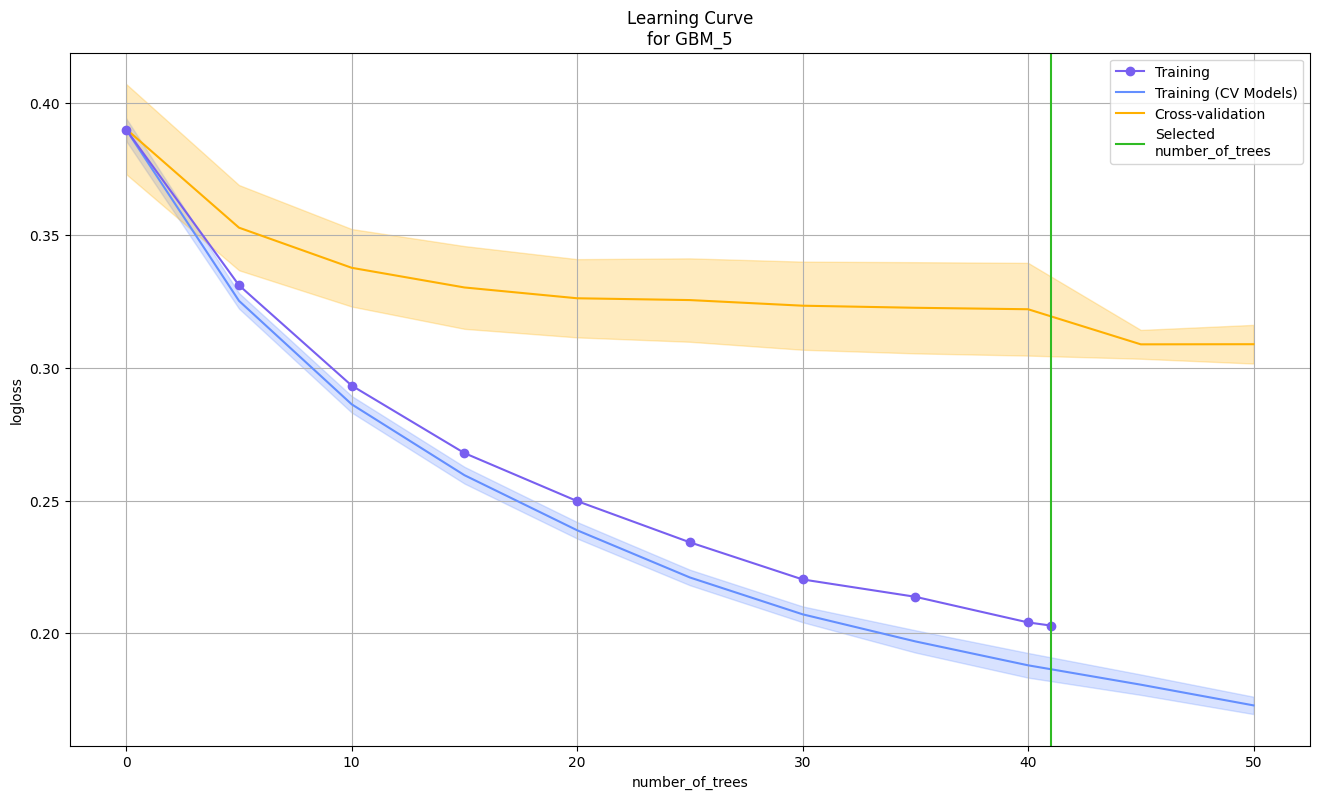

# Variable Importance

> The variable importance plot shows the relative importance of the most important variables in the model.

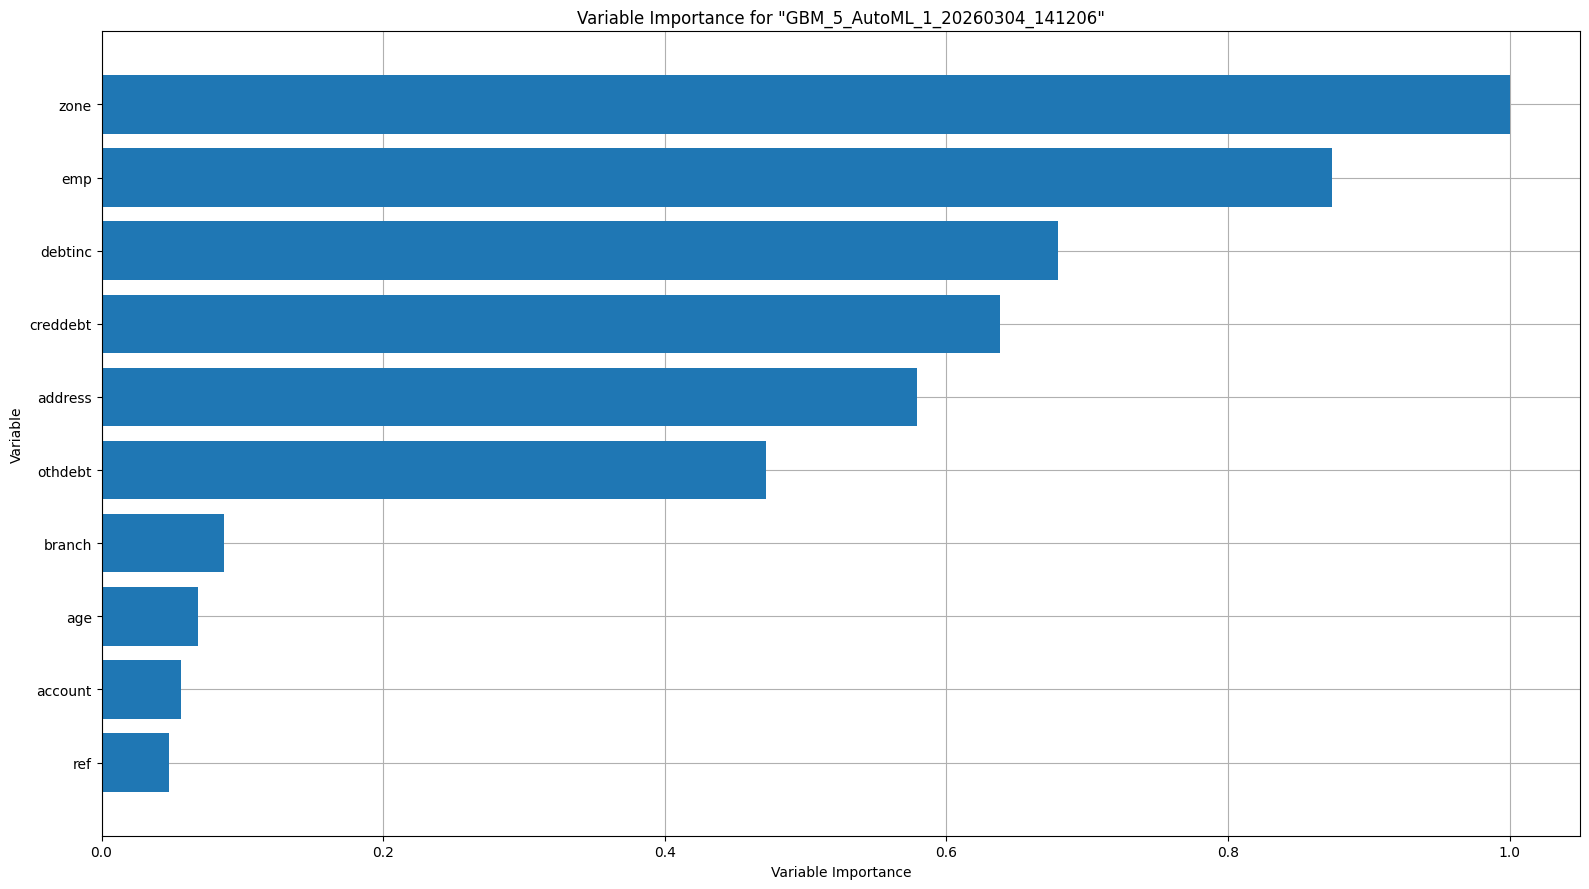

# SHAP Summary

> SHAP summary plot shows the contribution of the features for each instance (row of data). The sum of the feature contributions and the bias term is equal to the raw prediction of the model, i.e., prediction before applying inverse link function.

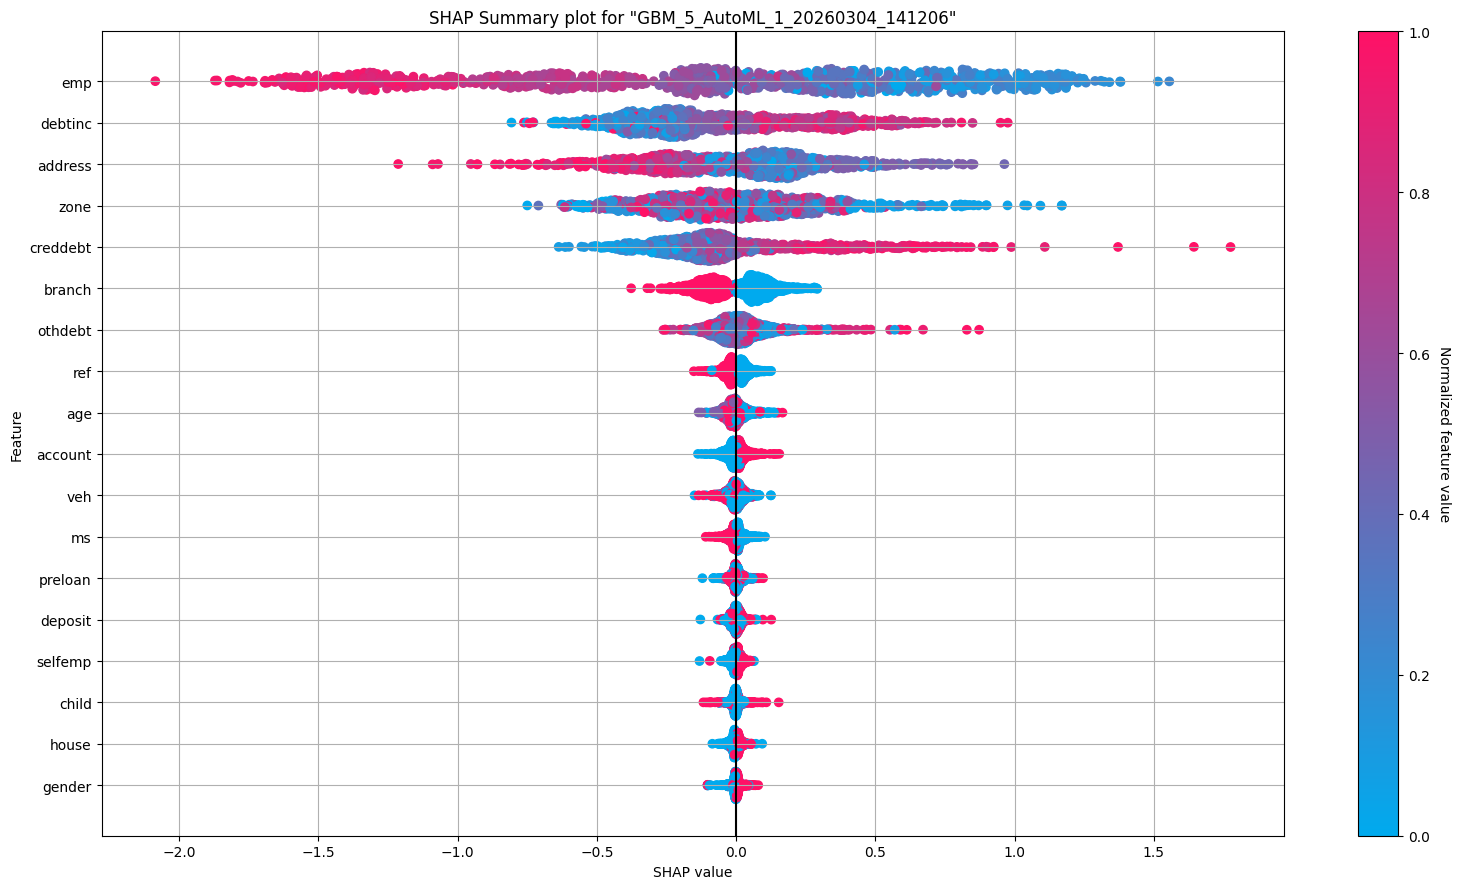

# Partial Dependence Plots

> Partial dependence plot (PDP) gives a graphical depiction of the marginal effect of a variable on the response. The effect of a variable is measured in change in the mean response. PDP assumes independence between the feature for which is the PDP computed and the rest.

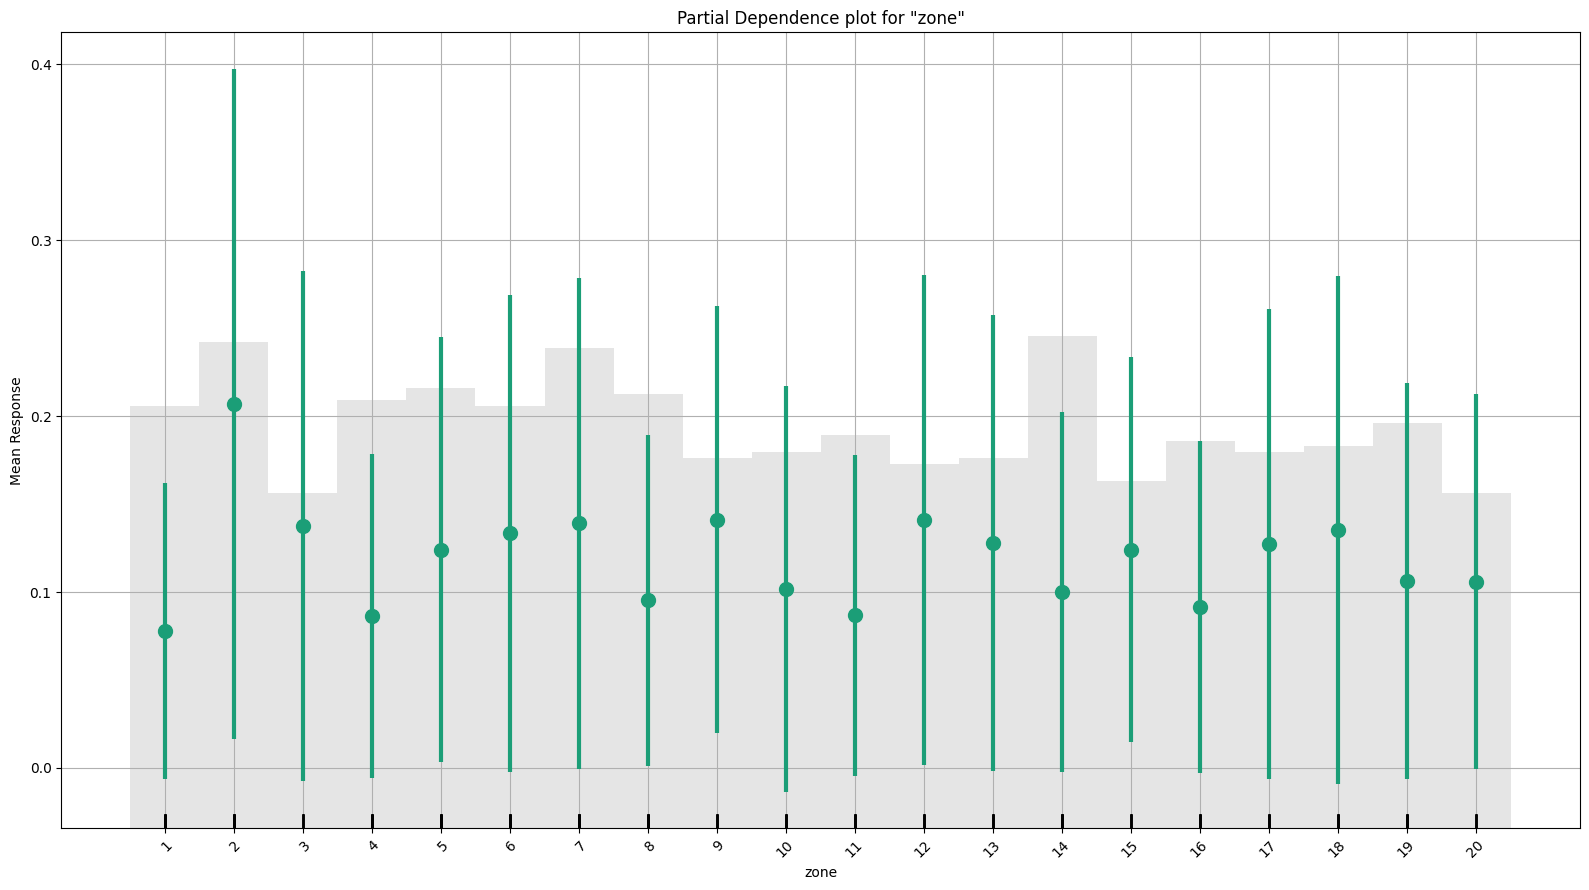

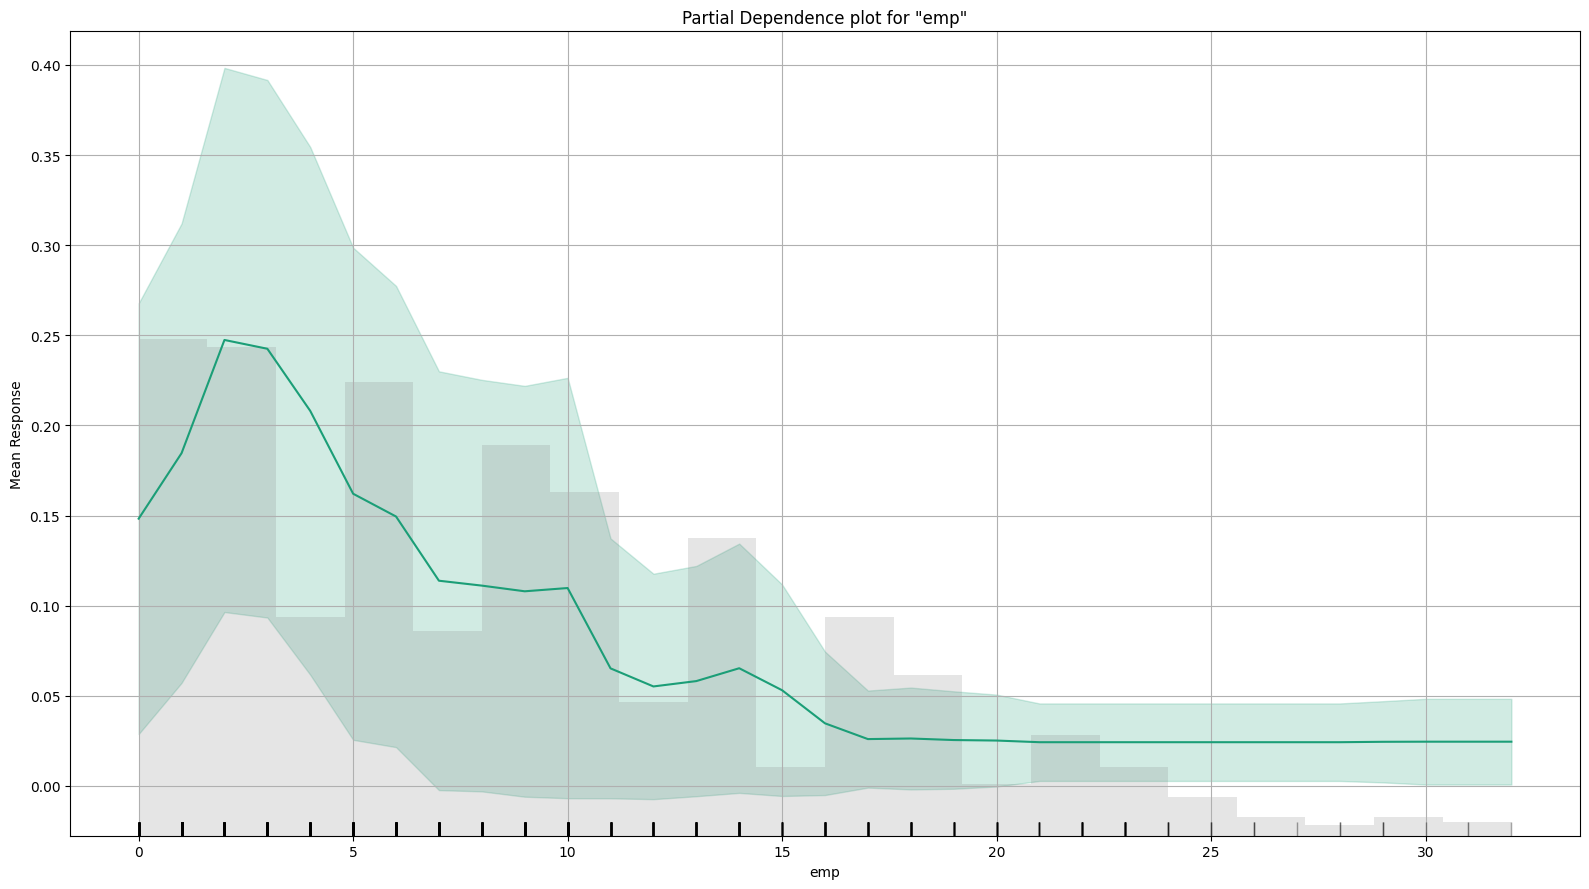

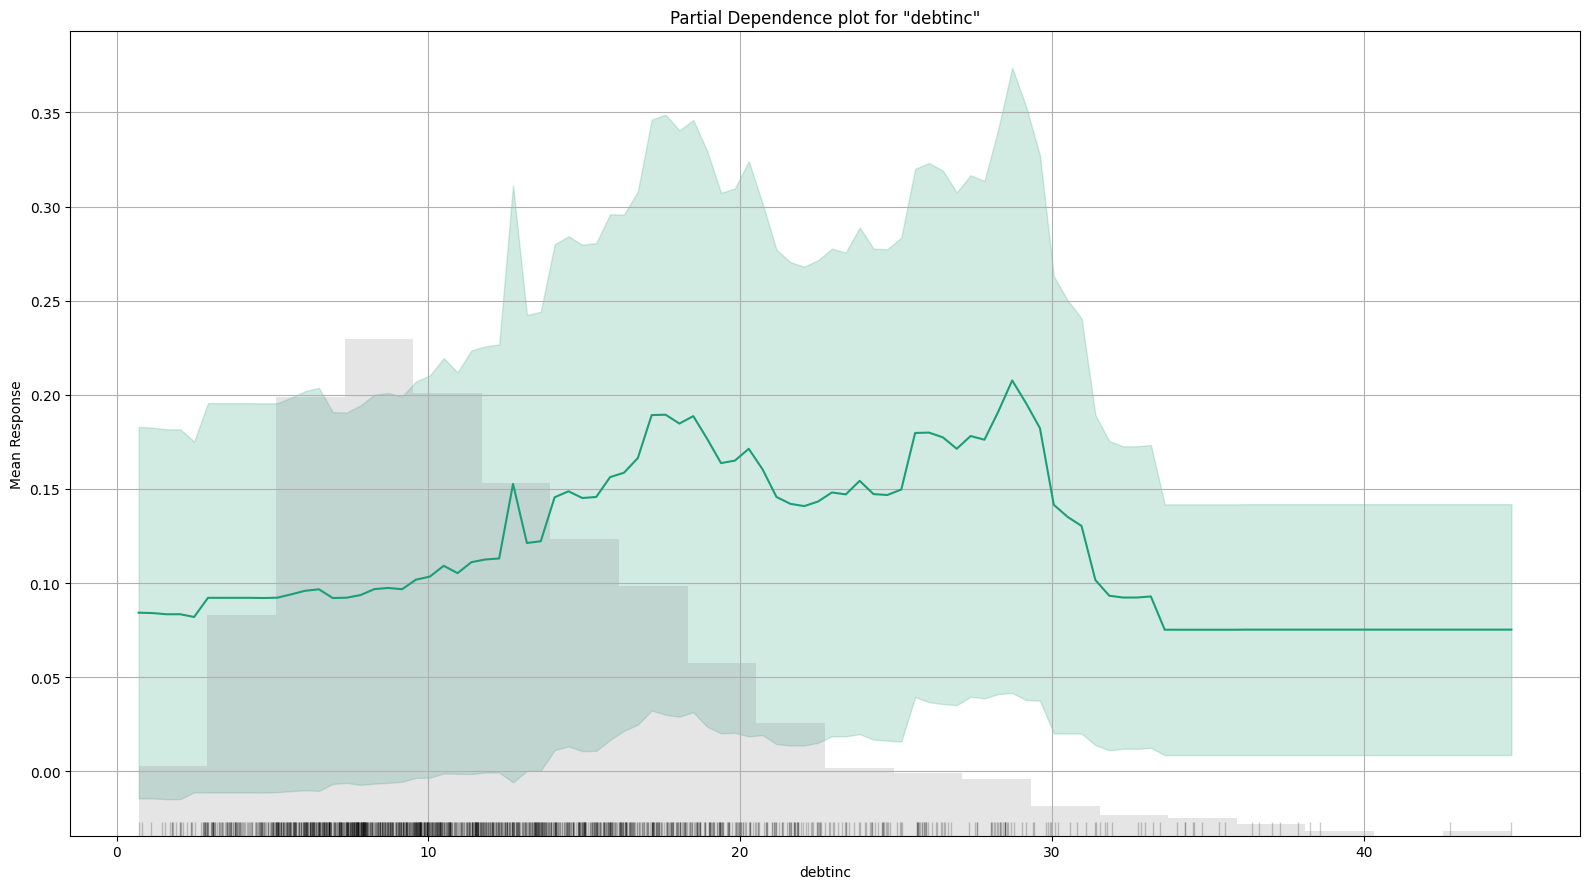

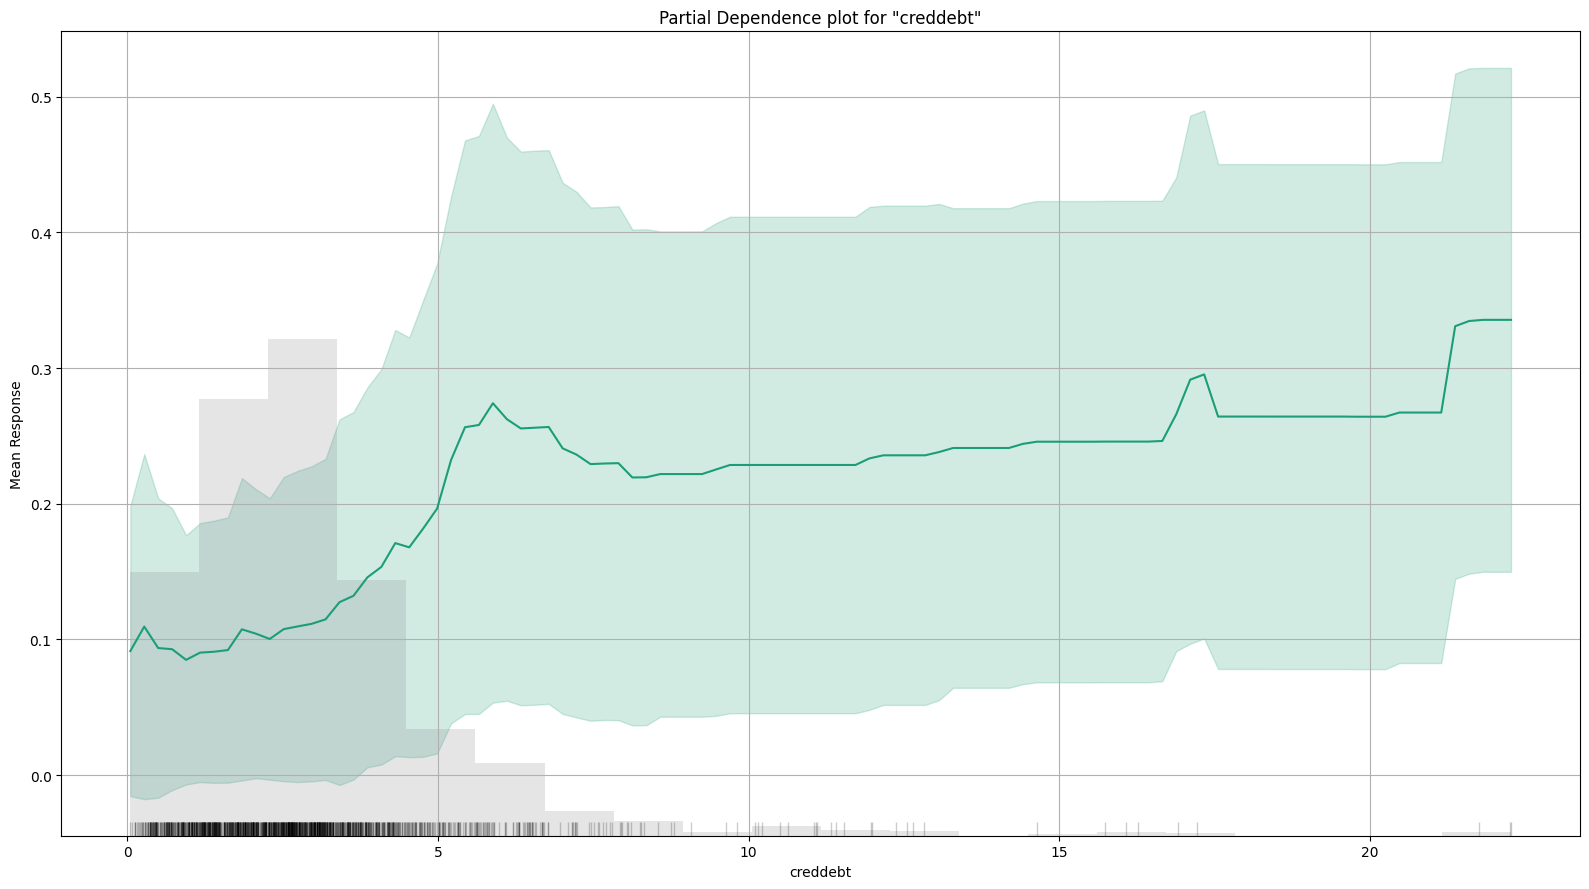

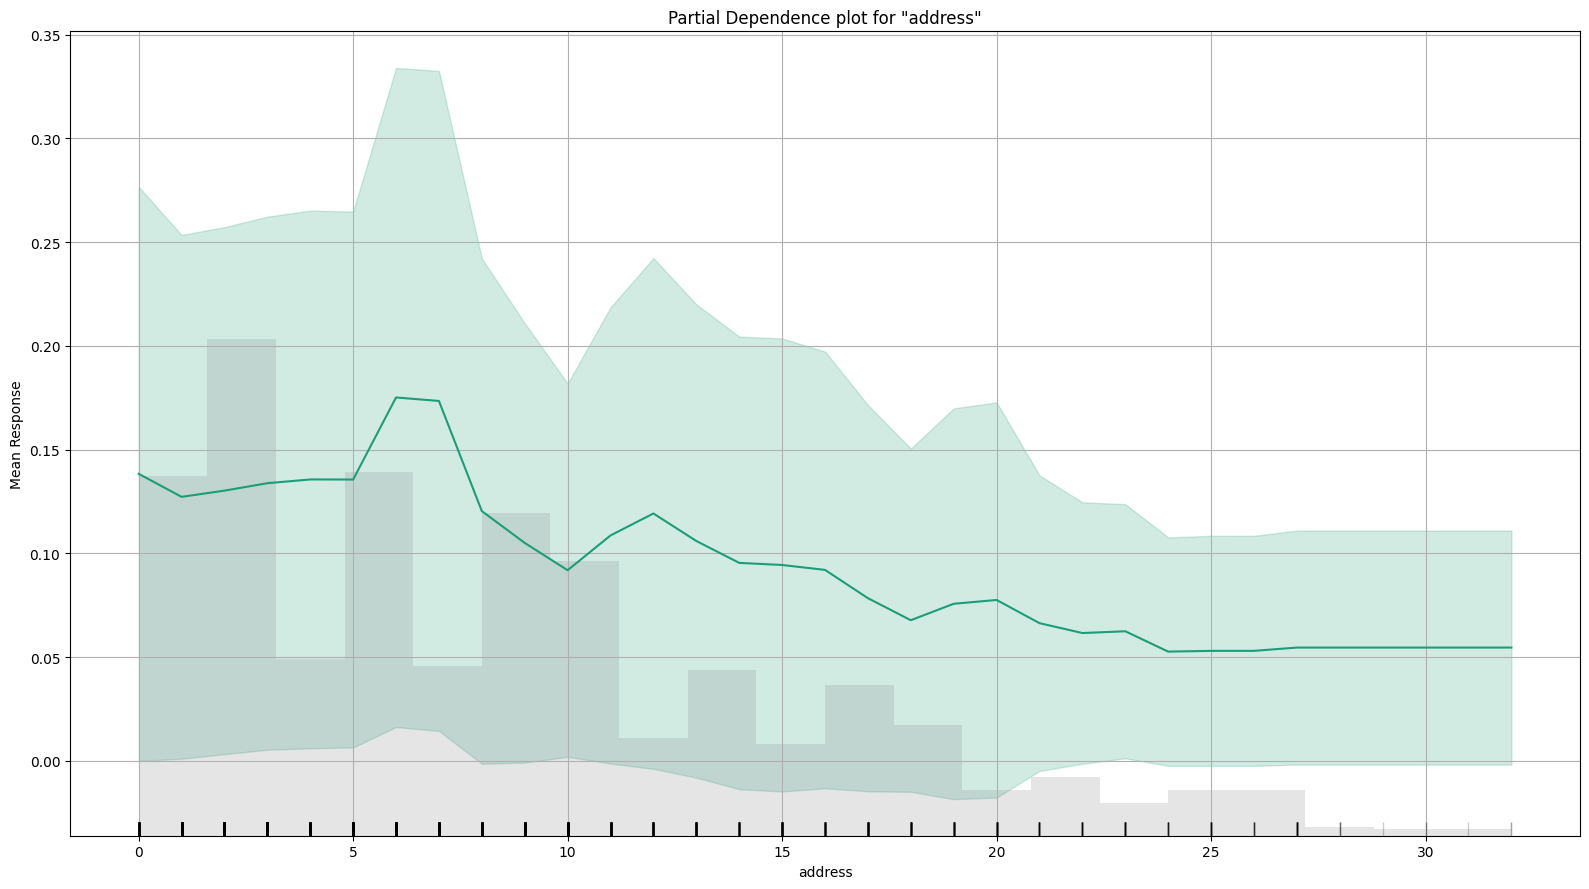

In [11]:
best_model.explain(test);

### SHAP interpretation:
- Top features = most important

- Right = increases probability of bad

- Left = decreases probability of bad

- Red/Blue = high/low feature value effect

Example interpretation:

- For emp:
Red dots mostly on left → higher employment years reduce bad risk.

- For debtinc:
Red dots on right → higher debt income increases bad risk.


### 10. Model Performance Evaluation

The `model_performance()` function evaluates a trained model on train/validation/test data and returns key performance metrics.

In [12]:
best_model.model_performance(test_data=test)

ModelMetricsBinomial: gbm
** Reported on test data. **

MSE: 0.10253816089791046
RMSE: 0.3202158036354709
LogLoss: 0.3333959890580528
Mean Per-Class Error: 0.2967714569971752
AUC: 0.7853434185513528
AUCPR: 0.3525980645306274
Gini: 0.5706868371027056

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.13482166696691691
       0    1    Error    Rate
-----  ---  ---  -------  --------------
0      895  309  0.2566   (309.0/1204.0)
1      63   124  0.3369   (63.0/187.0)
Total  958  433  0.2674   (372.0/1391.0)

Maximum Metrics: Maximum metrics at their respective thresholds
metric                       threshold    value     idx
---------------------------  -----------  --------  -----
max f1                       0.134822     0.4       223
max f2                       0.0908647    0.580882  268
max f0point5                 0.271769     0.361963  109
max accuracy                 0.607421     0.870597  8
max precision                0.857634     1         0
max recall                   0.0263728    1         360
max specificity              0.857634     1         0
max absolute_mcc             0.0908647    0.321507  268
max min_per_class_accuracy   0.116851     0.700535  238
max mean_per_class_accuracy  0.0908647    0.733922  268
max tns                      0.857634     1204      0
max fns                      0.857634     186       0
max fps                      0.00583358   1204      399
max tps                      0.0263728    187       360
max tnr                      0.857634     1         0
max fnr                      0.857634     0.994652  0
max fpr                      0.00583358   1         399
max tpr                      0.0263728    1         360

Gains/Lift Table: Avg response rate: 13.44 %, avg score: 11.89 %
group    cumulative_data_fraction    lower_threshold    lift      cumulative_lift    response_rate    score      cumulative_response_rate    cumulative_score    capture_rate    cumulative_capture_rate    gain      cumulative_gain    kolmogorov_smirnov
-------  --------------------------  -----------------  --------  -----------------  ---------------  ---------  --------------------------  ------------------  --------------  -------------------------  --------  -----------------  --------------------
1        0.0100647                   0.570098           4.25057   4.25057            0.571429         0.672299   0.571429                    0.672299            0.0427807       0.0427807                  325.057   325.057            0.0377974
2        0.0201294                   0.508062           4.25057   4.25057            0.571429         0.537579   0.571429                    0.604939            0.0427807       0.0855615                  325.057   325.057            0.0755947
3        0.0301941                   0.456622           2.65661   3.71925            0.357143         0.483113   0.5                         0.56433             0.026738        0.112299                   165.661   271.925            0.0948576
4        0.0402588                   0.423058           2.65661   3.45359            0.357143         0.437547   0.464286                    0.532634            0.026738        0.139037                   165.661   245.359            0.11412
5        0.0503235                   0.387808           2.65661   3.29419            0.357143         0.406826   0.442857                    0.507473            0.026738        0.165775                   165.661   229.419            0.133383
6        0.100647                    0.286215           2.23155   2.76287            0.3              0.337345   0.371429                    0.422409            0.112299        0.278075                   123.155   176.287            0.204985
7        0.150252                    0.229264           1.83267   2.45577            0.246377         0.253617   0.330144                    0.366683            0.0909091       0.368984                   83.2675   145.577            0.252705
8        0.200575                    0.193